運用SVM、隨機森林、決策樹進行監督式學習之模型訓練和判斷之比較

In [2]:
# prompt: 請讀取Churn_Modelling.csv，並顯示其前五行

import pandas as pd

# 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 顯示前五行資料
data.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [3]:
# prompt: 請將資料中的RowNumber、CustomerId、Surname之欄位數據進行移除 （資料預處理）

import pandas as pd
# 運用SVM、隨機森林、決策樹進行監督式學習之模型訓練和判斷之比較


# 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 移除指定欄位
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 顯示前五行資料
data.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [4]:
# prompt: 請對資料判斷是否有缺失值

import pandas as pd

# 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 檢查缺失值
print(data.isnull().sum())


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64


In [5]:
# prompt: 接下來請對 Geography利用眾數補值，Age用中位數來補值，而 HasCrCard、IsActiveMember 則是用衆數來補值 （資料預處理）

import pandas as pd

# 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 移除指定欄位
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 使用眾數填補 Geography 的缺失值
data['Geography'] = data['Geography'].fillna(data['Geography'].mode()[0])

# 使用中位數填補 Age 的缺失值
data['Age'] = data['Age'].fillna(data['Age'].median())

# 使用眾數填補 HasCrCard 的缺失值
data['HasCrCard'] = data['HasCrCard'].fillna(data['HasCrCard'].mode()[0])

# 使用眾數填補 IsActiveMember 的缺失值
data['IsActiveMember'] = data['IsActiveMember'].fillna(data['IsActiveMember'].mode()[0])

# 檢查缺失值
print(data.isnull().sum())


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [6]:
# prompt: 請將資料中的 Gender 的欄位進行Label Encoding，而 Geography 的欄位則是進行 One-hot Enocoding，以做到類別特徵之轉換（數據類型轉換）

import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np

# Label Encoding for Gender
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

# One-Hot Encoding for Geography
geo_ohe = OneHotEncoder()
geo_encoded = geo_ohe.fit_transform(data[['Geography']]).toarray()
geo_encoded_df = pd.DataFrame(geo_encoded, columns=geo_ohe.get_feature_names_out(['Geography']))

# Concatenate the encoded features with the original dataframe
data = pd.concat([data, geo_encoded_df], axis=1)
data = data.drop('Geography', axis=1)

# Display the first five rows of the modified data
data.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42.0,2,0.00,1,1.0,1.0,101348.88,1,1.0,0.0,0.0
1,608,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0,0.0,0.0,1.0
2,502,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1,1.0,0.0,0.0
3,699,0,39.0,1,0.00,2,0.0,0.0,93826.63,0,1.0,0.0,0.0
4,850,0,43.0,2,125510.82,1,1.0,1.0,79084.10,0,0.0,0.0,1.0


In [7]:
# prompt: 請針對以上資料進行決策樹分類建模，特徵變數：CreditScore	Gender	Age	Tenure	Balance	NumOfProducts	HasCrCard	IsActiveMember	EstimatedSalary Geography_France	Geography_Germany	Geography_Spain
# ，目標變數：Exited，顯示該模型之參數並進行初始化（先不用進行訓練，但先設定目標變數和特徵變數）

from sklearn.tree import DecisionTreeClassifier

# Define features (X) and target (y)
X = data[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = data['Exited']

# Initialize the Decision Tree Classifier with default parameters
dt_classifier = DecisionTreeClassifier()

# Print the model parameters
dt_classifier.get_params()


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [8]:
# prompt: 接下來請以訓練資料及測試資料比率為9：1，並顯示其各部分資料筆數，樹的深度設定爲5，訓練及評估決策樹模型

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Print the number of samples in each set
print("Training data:", X_train.shape[0])
print("Testing data:", X_test.shape[0])

# Initialize the Decision Tree Classifier with max_depth=5
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report
y_pred = dt_classifier.predict(X_test)

# Print the accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Training data: 9001
Testing data: 1001
Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       803
           1       0.82      0.36      0.50       198

    accuracy                           0.86      1001
   macro avg       0.84      0.67      0.71      1001
weighted avg       0.85      0.86      0.83      1001



In [9]:
# prompt: 接下來請改以訓練資料及測試資料比率為8：2，並顯示其各部分資料筆數，樹的深度設定爲5，訓練及評估決策樹模型

# Split data into training and testing sets with an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the number of samples in each set
print("Training data:", X_train.shape[0])
print("Testing data:", X_test.shape[0])

# Initialize the Decision Tree Classifier with max_depth=5
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred = dt_classifier.predict(X_test)

# Print the accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Training data: 8001
Testing data: 2001
Accuracy: 0.8555722138930535
              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1599
           1       0.76      0.41      0.53       402

    accuracy                           0.86      2001
   macro avg       0.81      0.69      0.72      2001
weighted avg       0.85      0.86      0.84      2001



In [10]:
# prompt: 接下來請改以訓練資料及測試資料比率為7：3，並顯示其各部分資料筆數，樹的深度設定爲5，訓練及評估決策樹模型

# Split data into training and testing sets with a 70/30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the number of samples in each set
print("Training data:", X_train.shape[0])
print("Testing data:", X_test.shape[0])

# Initialize the Decision Tree Classifier with max_depth=5
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred = dt_classifier.predict(X_test)

# Print the accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Training data: 7001
Testing data: 3001
Accuracy: 0.8563812062645785
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2401
           1       0.78      0.40      0.52       600

    accuracy                           0.86      3001
   macro avg       0.82      0.68      0.72      3001
weighted avg       0.85      0.86      0.84      3001



In [11]:
# prompt: 接下來請改以訓練資料及測試資料比率為6：4，並顯示其各部分資料筆數，樹的深度設定爲5，訓練及評估決策樹模型

# Split data into training and testing sets with a 60/40 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Print the number of samples in each set
print("Training data:", X_train.shape[0])
print("Testing data:", X_test.shape[0])

# Initialize the Decision Tree Classifier with max_depth=5
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred = dt_classifier.predict(X_test)

# Print the accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Training data: 6001
Testing data: 4001
Accuracy: 0.8545363659085229
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      3196
           1       0.77      0.39      0.52       805

    accuracy                           0.85      4001
   macro avg       0.82      0.68      0.72      4001
weighted avg       0.85      0.85      0.84      4001



Confusion Matrix:
[[787  16]
 [127  71]]


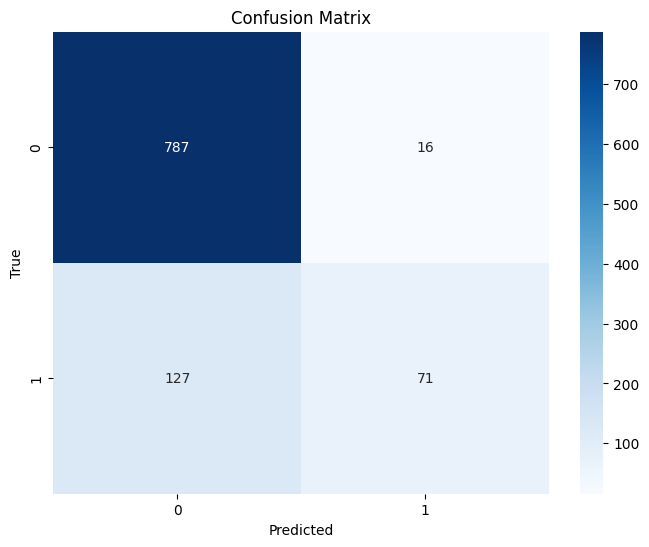


Accuracy: 0.8571428571428571

Precision: 0.8160919540229885

Recall: 0.35858585858585856

F1 Score: 0.4982456140350877


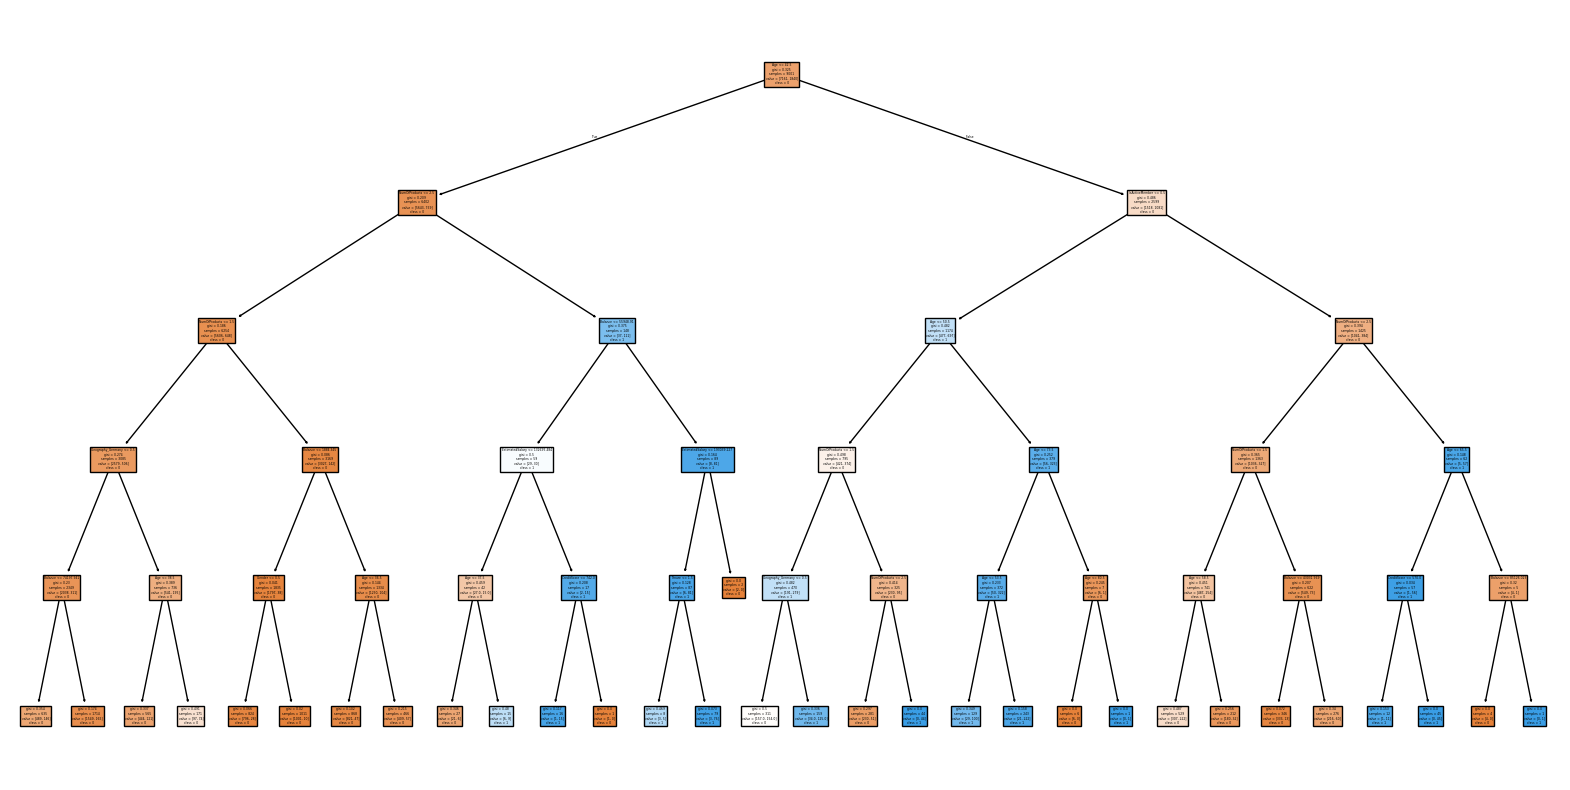

In [12]:
# prompt: 接下來請以訓練資料及測試資料比率為9：1來訓練的模型爲基準，來進行預測結果的評估（混淆矩陣、accuracy、precision、recall、f1 score、畫出樹狀圖形等）

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn import tree

# Split data into training and testing sets with a 90/10 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nPrecision:", precision_score(y_test, y_pred))
print("\nRecall:", recall_score(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))


# Plot the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_classifier, feature_names=X.columns, class_names=['0','1'], filled=True)
plt.show()


In [ ]:
# prompt: 請讀取Churn_Modelling.csv，並顯示其前五行

import pandas as pd

# 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 顯示前五行資料
data.head()

# prompt: 請將資料中的RowNumber、CustomerId、Surname之欄位數據進行移除 （資料預處理）

import pandas as pd
# 運用SVM、隨機森林、決策樹進行監督式學習之模型訓練和判斷之比較


# 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 移除指定欄位
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 顯示前五行資料
data.head()

# prompt: 請對資料判斷是否有缺失值

import pandas as pd

# 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 檢查缺失值
print(data.isnull().sum())

# prompt: 接下來請對 Geography利用眾數補值，Age用中位數來補值，而 HasCrCard、IsActiveMember 則是用衆數來補值 （資料預處理）

import pandas as pd

# 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 移除指定欄位
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 使用眾數填補 Geography 的缺失值
data['Geography'] = data['Geography'].fillna(data['Geography'].mode()[0])

# 使用中位數填補 Age 的缺失值
data['Age'] = data['Age'].fillna(data['Age'].median())

# 使用眾數填補 HasCrCard 的缺失值
data['HasCrCard'] = data['HasCrCard'].fillna(data['HasCrCard'].mode()[0])

# 使用眾數填補 IsActiveMember 的缺失值
data['IsActiveMember'] = data['IsActiveMember'].fillna(data['IsActiveMember'].mode()[0])

# 檢查缺失值
print(data.isnull().sum())


#prompt: 請將資料中的 Gender 的欄位進行Label Encoding，而 Geography 的欄位則是進行 One-hot Enocoding，以做到類別特徵之轉換（數據類型轉換）

import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np

# Label Encoding for Gender
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

# One-Hot Encoding for Geography
geo_ohe = OneHotEncoder()
geo_encoded = geo_ohe.fit_transform(data[['Geography']]).toarray()
geo_encoded_df = pd.DataFrame(geo_encoded, columns=geo_ohe.get_feature_names_out(['Geography']))

# Concatenate the encoded features with the original dataframe
data = pd.concat([data, geo_encoded_df], axis=1)
data = data.drop('Geography', axis=1)

# Display the first five rows of the modified data
data.head()

# prompt: 請針對以上資料進行決策樹分類建模，特徵變數：CreditScore	Gender	Age	Tenure	Balance	NumOfProducts	HasCrCard	IsActiveMember	EstimatedSalary Geography_France	Geography_Germany	Geography_Spain
# ，目標變數：Exited，顯示該模型之參數並進行初始化（先不用進行訓練，但先設定目標變數和特徵變數）

from sklearn.tree import DecisionTreeClassifier

# Define features (X) and target (y)
X = data[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = data['Exited']

# Initialize the Decision Tree Classifier with default parameters
dt_classifier = DecisionTreeClassifier()

# Print the model parameters
dt_classifier.get_params()
# prompt: 接下來請以訓練資料及測試資料比率為9：1，並顯示其各部分資料筆數，樹的深度設定爲5，訓練及評估決策樹模型

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Print the number of samples in each set
print("Training data:", X_train.shape[0])
print("Testing data:", X_test.shape[0])

# Initialize the Decision Tree Classifier with max_depth=5
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report
y_pred = dt_classifier.predict(X_test)

# Print the accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# prompt: 接下來請以訓練資料及測試資料比率為9：1來訓練的模型爲基準，來進行預測結果的評估（混淆矩陣、accuracy、precision、recall、f1 score、畫出樹狀圖形等）

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn import tree

# Split data into training and testing sets with a 90/10 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nPrecision:", precision_score(y_test, y_pred))
print("\nRecall:", recall_score(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))


# Plot the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_classifier, feature_names=X.columns, class_names=['0','1'], filled=True)
plt.show()




各欄位缺失值數量：
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

資料中仍有缺失值。

缺失值填補後：
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

轉換後資料前五行：
   CreditScore  Gender   Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0  42.0       2       0.00              1        1.0   
1          608       0  41.0       1   83807.86              1        0.0   
2          502       0  42.0       8  159660.80              3        1.0   
3          699       0  39.0       1       0.00              2        0.0   
4          850       0  43.0       2  125510.82              1        1.0   

   IsAc

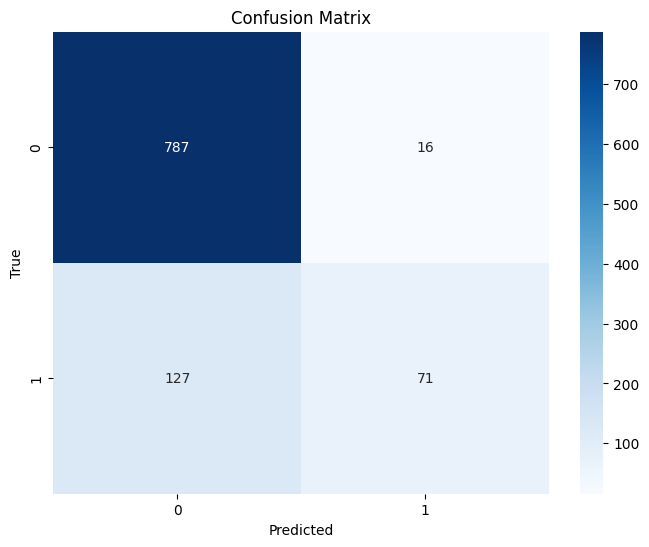

Accuracy: 0.8571428571428571
Precision: 0.8160919540229885
Recall: 0.35858585858585856
F1 Score: 0.4982456140350877

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92       803
           1       0.82      0.36      0.50       198

    accuracy                           0.86      1001
   macro avg       0.84      0.67      0.71      1001
weighted avg       0.85      0.86      0.83      1001



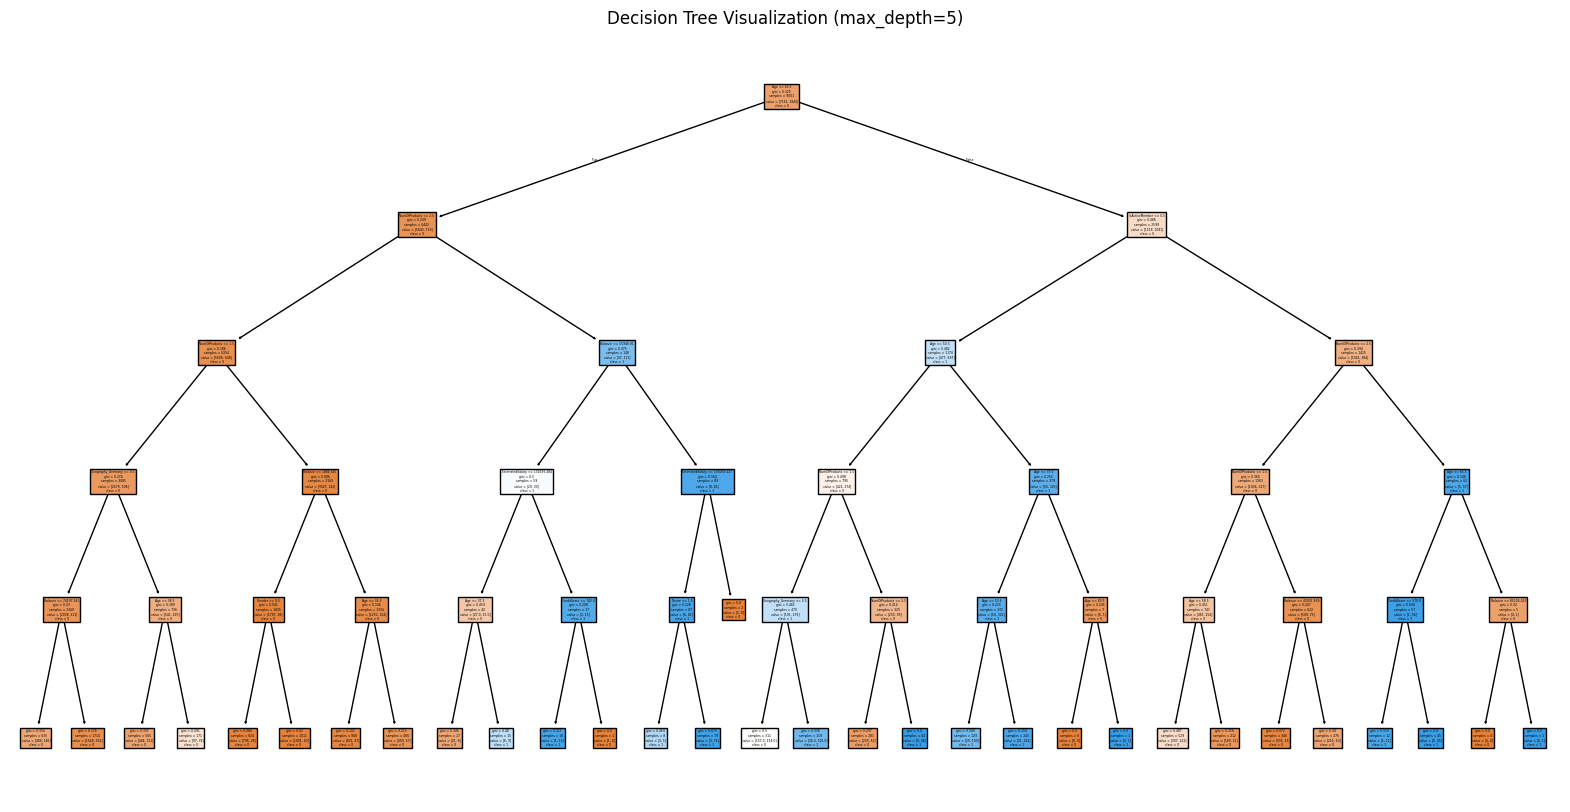

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn 相關匯入
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn import tree
from matplotlib.colors import ListedColormap

# 1. 讀取 CSV 檔案
data = pd.read_csv('Churn_Modelling.csv')

# 2. 移除不必要的欄位: RowNumber, CustomerId, Surname
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)


# 3. 檢查缺失值
print("\n各欄位缺失值數量：")
print(data.isnull().sum())
if data.isnull().values.any():
    print("\n資料中仍有缺失值。")
else:
    print("\n資料中沒有缺失值。")


# 4. 缺失值填補
# Geography：以眾數補值
# Age：以中位數補值
# HasCrCard, IsActiveMember：以眾數補值
data['Geography'] = data['Geography'].fillna(data['Geography'].mode()[0])
data['Age'] = data['Age'].fillna(data['Age'].median())
data['HasCrCard'] = data['HasCrCard'].fillna(data['HasCrCard'].mode()[0])
data['IsActiveMember'] = data['IsActiveMember'].fillna(data['IsActiveMember'].mode()[0])

print("\n缺失值填補後：")
print(data.isnull().sum())


# 5. 類別特徵轉換
# Label Encoding for Gender
# One-Hot Encoding for Geography
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geo_encoded = ohe.fit_transform(data[['Geography']])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out(['Geography']))
data = pd.concat([data.drop('Geography', axis=1), geo_encoded_df], axis=1)

print("\n轉換後資料前五行：")
print(data.head())


# 6. 定義特徵與標籤
# 特徵變數包含：CreditScore, Gender, Age, Tenure, Balance,
# NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary,
# Geography_France, Geography_Germany, Geography_Spain
features = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
            'Geography_France', 'Geography_Germany', 'Geography_Spain']
X = data[features]
y = data['Exited']


# 7. 決策樹模型初始化（僅顯示模型參數）
# 使用預設參數先進行初始化
dt_classifier = DecisionTreeClassifier()
print("\nDecision Tree 的初始參數：")
print(dt_classifier.get_params())


# 8. 分割資料 (訓練：測試 = 9:1) 並顯示各部分資料筆數
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print("\n訓練資料筆數:", X_train.shape[0])
print("測試資料筆數:", X_test.shape[0])

# 9. 決策樹模型建立、訓練與預測
# 設定樹的最大深度為5
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred = dt_classifier.predict(X_test)

### 6. 評估模型
print("\n--- Model Evaluation ---")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 11. 繪製決策樹圖形
plt.figure(figsize=(20,10))
tree.plot_tree(dt_classifier, feature_names=X.columns, class_names=['0','1'], filled=True)
plt.title("Decision Tree Visualization (max_depth=5)")
plt.show()
